# Algorithmic Trading Strategy: Predicting AAPL Stock Direction

### **1. Project Objective**
The goal of this project is to develop and evaluate a machine learning-based trading strategy for Apple Inc. (AAPL) stock. We aim to predict the daily direction of the stock (**Up** or **Down**) to generate profitable buy/sell signals.

### **2. Methodology**
Our approach involves three key steps:
* **Feature Engineering:** Calculating technical indicators (RSI, Moving Averages, Volatility) to capture market momentum.
* **Modeling:** Comparing three distinct algorithms:
    * *Decision Tree* (Baseline)
    * *Random Forest* (Ensemble Method)
    * *Markov Chain* (Probabilistic Model)
* **Backtesting:** Simulating a trading strategy to measure real-world performance (Equity Curve, ROI) and risk management.

### **3. Tech Stack**
* **Data:** `yfinance` (Yahoo Finance API)
* **Analysis:** `pandas`, `numpy`, `ta` (Technical Analysis Library)
* **Machine Learning:** `scikit-learn`
* **Visualization:** `matplotlib`, `seaborn`

In [256]:
# Note: If running this notebook for the first time, uncomment and run:
# !pip install yfinance ta

import pandas as pd
import numpy as np
import yfinance as yf 
import ta 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from ta.momentum import RSIIndicator
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

# System settings
import warnings
warnings.filterwarnings('ignore') 

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use("seaborn-v0_8")  

# Download historical data
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31")
data.reset_index(inplace=True)   # Reset index to restore 'Date' as a normal column

data.columns = [col[0] for col in data.columns]   # Flatten MultiIndex to clean column names

from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np
import pandas as pd

[*********************100%***********************]  1 of 1 completed


In [257]:
data.head()  # Display the first 5 rows of the dataframe

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.468269,72.528589,71.223267,71.476607,135480400
1,2020-01-03,71.763710,72.523738,71.539322,71.696152,146322800
2,2020-01-06,72.335571,72.374177,70.634554,70.885487,118387200
3,2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000
4,2020-01-08,73.153503,73.455103,71.698589,71.698589,132079200


In [258]:
data.columns  

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [262]:
data.describe() # Display descriptive statistics for the dataset

,Date,Close,High,Low,Open,Volume
count,1503,1503.000000,1503.000000,1503.000000,1503.000000,1.503000e+03
mean,2022-12-27 00:44:04.311377152,164.581051,166.266738,162.727566,164.420412,8.473287e+07
min,2020-01-02 00:00:00,54.264336,55.263186,51.420157,55.161608,1.350248e+07
25%,2021-06-29 12:00:00,131.372887,132.738433,130.018809,131.636299,5.096430e+07
50%,2022-12-23 00:00:00,163.163315,165.053583,161.838890,163.247552,7.044060e+07
75%,2024-06-25 12:00:00,196.211769,198.810159,194.036944,195.924703,1.007082e+08
max,2025-12-23 00:00:00,286.190002,288.619995,283.299988,286.200012,4.265100e+08
std,NaN,49.405791,49.702789,49.055840,49.363383,5.133762e+07


In [264]:
data.isnull().any() # Check for missing values (NaN) to ensure the dataset is complete

Date      False
Close     False
High      False
Low       False
Open      False
Volume    False
dtype: bool

In [266]:
data["Target"] = (data["Close"].shift(-1) > data["Close"]).astype(int) # Target = trend (1 if Up, 0 if Down)

In [268]:
print (data)

           Date       Close        High         Low        Open     Volume  \
0    2020-01-02   72.468269   72.528589   71.223267   71.476607  135480400   
1    2020-01-03   71.763710   72.523738   71.539322   71.696152  146322800   
2    2020-01-06   72.335571   72.374177   70.634554   70.885487  118387200   
3    2020-01-07   71.995354   72.600960   71.775789   72.345204  108872000   
4    2020-01-08   73.153503   73.455103   71.698589   71.698589  132079200   
...         ...         ...         ...         ...         ...        ...   
1498 2025-12-17  271.839996  276.160004  271.640015  275.010010   50138700   
1499 2025-12-18  272.190002  273.630005  266.950012  273.609985   51630700   
1500 2025-12-19  273.670013  274.600006  269.899994  272.149994  144632000   
1501 2025-12-22  270.970001  273.880005  270.510010  272.859985   36492700   
1502 2025-12-23  271.600006  272.311188  269.559998  270.839996   13502482   

      Target  
0          0  
1          1  
2          0  
3  

In [270]:
data["Return"] = data["Close"].pct_change() # Calculate daily returns
data["Volatility"] = data["Return"].rolling(5).std() # 5-day volatility 
data["MA5"] = data["Close"].rolling(5).mean() # Short-term moving average 
data["MA20"] = data["Close"].rolling(20).mean() # Long-term moving average 
data["RSI14"] = RSIIndicator(data["Close"], window=14).rsi() # RSI measures momentum: <30 oversold, >70 overbought

In [272]:
data = data.dropna()
print(data)

           Date       Close        High         Low        Open     Volume  \
19   2020-01-30   78.143135   78.196217   76.907786   77.339678  126743200   
20   2020-01-31   74.678391   77.856036   74.384029   77.433797  199588400   
21   2020-02-03   74.473289   75.638666   72.919450   73.421308  173788400   
22   2020-02-04   76.931931   77.122543   75.672452   76.077799  136616400   
23   2020-02-05   77.559280   78.357915   76.956082   78.058723  118826800   
...         ...         ...         ...         ...         ...        ...   
1498 2025-12-17  271.839996  276.160004  271.640015  275.010010   50138700   
1499 2025-12-18  272.190002  273.630005  266.950012  273.609985   51630700   
1500 2025-12-19  273.670013  274.600006  269.899994  272.149994  144632000   
1501 2025-12-22  270.970001  273.880005  270.510010  272.859985   36492700   
1502 2025-12-23  271.600006  272.311188  269.559998  270.839996   13502482   

      Target    Return  Volatility         MA5        MA20     

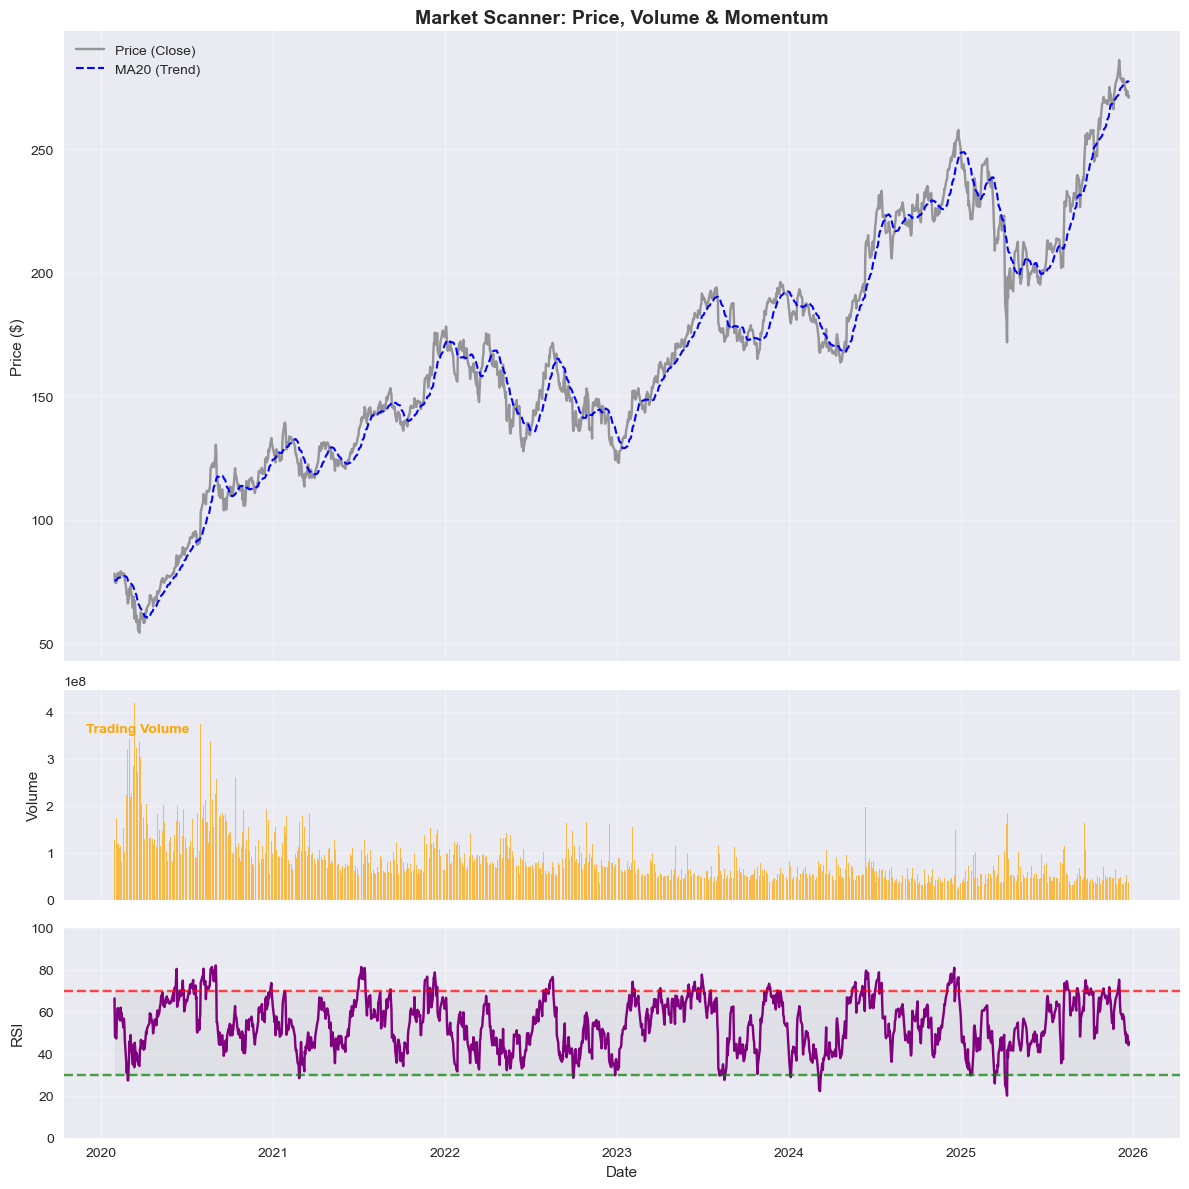

In [274]:
# --- Market Scanner Visualization ---
# This plot combines Price, Volume, and RSI to analyze market structure.

# Height ratios: Price is the biggest (3), then Volume (1), then RSI (1)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# 1. Price & Moving Averages 
ax1.plot(data["Date"], data["Close"], label="Price (Close)", color='gray', alpha=0.8)
ax1.plot(data["Date"], data["MA20"], label="MA20 (Trend)", color='blue', linestyle='--', linewidth=1.5)
ax1.set_title("Market Scanner: Price, Volume & Momentum", fontsize=14, fontweight='bold')
ax1.set_ylabel("Price ($)")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Trading Volume 
ax2.bar(data["Date"], data["Volume"], color='orange', alpha=0.7, width=1.0)
ax2.set_ylabel("Volume")
ax2.grid(True, alpha=0.3)
ax2.text(0.02, 0.8, 'Trading Volume', transform=ax2.transAxes, fontsize=10, fontweight='bold', color='orange')

# 3. RSI Indicator 
ax3.plot(data["Date"], data["RSI14"], color='purple', label="RSI (14)")
ax3.axhline(70, color='red', linestyle='--', alpha=0.7)
ax3.axhline(30, color='green', linestyle='--', alpha=0.7)
ax3.fill_between(data["Date"], 70, 30, color='gray', alpha=0.1) # Highlight the neutral zone
ax3.set_ylabel("RSI")
ax3.set_xlabel("Date")
ax3.set_ylim(0, 100) # RSI between 0 and 100
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [275]:
X = data[["Open", "High", "Low", "Close", "Volume", "Return", "Volatility", "MA5", "MA20", "RSI14"]]
y = data["Target"]

### **4. Data Splitting: Time Series Constraints**

Why `shuffle=False`?
In financial time series, standard random splitting  is dangerous because it leads to Data Leakage. It would allow the model to train on future data to predict the past, which is impossible in real trading.

To simulate a realistic scenario, we must respect chronological order:
* **Training Set:** The first 80% of history (The Past).
* **Testing Set:** The last 20% of history (The "Future" or Unseen data).

In [277]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [278]:
# TimeSeriesSplit: splits the data in chronological order
tscv = TimeSeriesSplit(n_splits=5)

### **5. Hyperparameter Tuning: Decision Tree**
To find the best model configuration, we perform a Grid Search.
Critically, we use `TimeSeriesSplit` instead of standard K-Fold to validate the model on chronological segments, preventing any data leakage from the future.

In [280]:
model_dt = DecisionTreeClassifier(random_state=42)

param_grid = {"max_depth": [ 5, 10, 20,None],"min_samples_split": [2, 5, 10, 20],"min_samples_leaf": [1, 5, 10,15],
              "criterion": ["gini", "entropy"],"max_features": [None, "sqrt", "log2"]}

grid = GridSearchCV(model_dt, param_grid, cv=tscv, scoring="f1", n_jobs=-1, verbose=1, refit=True)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 5, 10, 15],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1', verbose=1)

### **6. Model Evaluation: Decision Tree**
We evaluate the best Decision Tree on the Test Set.
* **F1-Score:** Balances precision and recall.
* **AUC :** Measures the ability to distinguish between Up and Down classes.

In [282]:
print("best parameters DTC:", grid.best_params_)
print("Best CV DTC F1-score :", grid.best_score_)
best_dt = grid.best_estimator_

y_pred = best_dt.predict(X_test)
auc_dt = roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1])
print("F1-score test :", f1_score(y_test, y_pred))
print("AUC Decision Tree :", auc_dt)
print("\nClassification Report :\n", classification_report(y_test, y_pred))

best parameters DTC: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV DTC F1-score : 0.525093348451818
F1-score test : 0.5681818181818182
AUC Decision Tree : 0.4677235401459855

Classification Report :
               precision    recall  f1-score   support

           0       0.43      0.33      0.37       137
           1       0.52      0.62      0.57       160

    accuracy                           0.49       297
   macro avg       0.47      0.48      0.47       297
weighted avg       0.48      0.49      0.48       297



### **Step 2: Confusion Matrix Visualization**
The Confusion Matrix helps us visualize the model's errors.
* **True Positives :** Correctly predicted market rise.
* **False Positives :** Model said "Buy", but market went Down (Risk of loss).

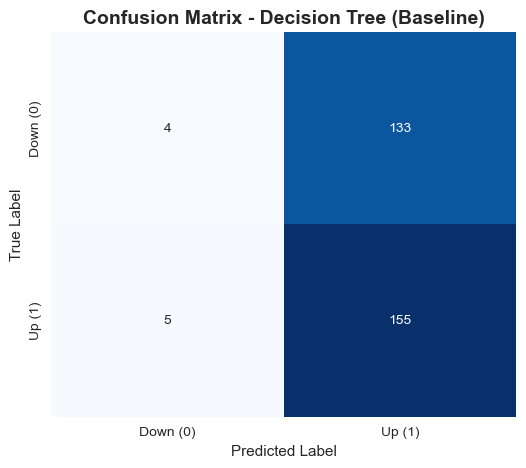

In [284]:
# Calculate the matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,xticklabels=["Down (0)", "Up (1)"],yticklabels=["Down (0)", "Up (1)"])

plt.title("Confusion Matrix - Decision Tree (Baseline)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False) # Turn off grid for cleaner heatmap
plt.show()

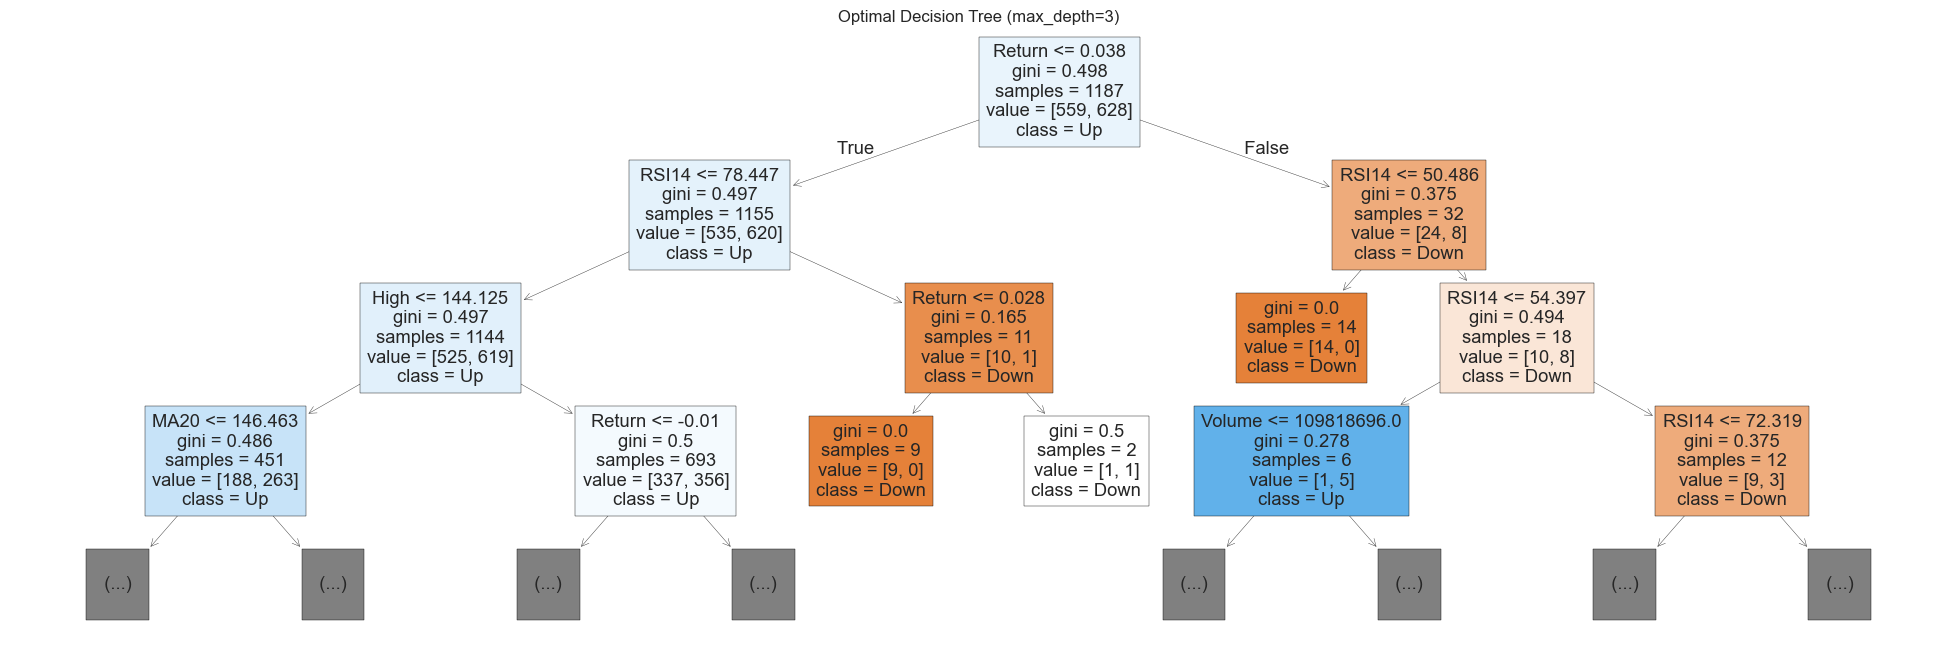

In [285]:
best_dt = grid.best_estimator_
plt.figure(figsize=(25, 8))
plot_tree(best_dt, max_depth=3, filled=True, feature_names=X_train.columns, class_names=["Down", "Up"])
plt.title("Optimal Decision Tree (max_depth=3)")
plt.show()

### **7. Hyperparameter Tuning: Random Forest with GridSearchCV**

In [297]:
# 'class_weight="balanced"' helps with the imbalance we observed earlier
model_rf = RandomForestClassifier(random_state=42, class_weight="balanced")

param_grid_rf = {"max_depth": [5, 10, 15, None],"min_samples_split": [2, 5, 10],"min_samples_leaf": [1, 5,10],
                 "n_estimators": [100, 200, 400], "max_features": [None, "sqrt", "log2"]  }

grid_rf = GridSearchCV(estimator=model_rf,param_grid=param_grid_rf,cv=tscv,scoring='f1',n_jobs=-1,verbose=1 )

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 400]},
             scoring='f1', verbose=1)

In [298]:
print("Best RF Parameters:", grid_rf.best_params_)
print("Best CV rf F1-score :", grid_rf.best_score_)
# Extract the best model for future use
best_rf = grid_rf.best_estimator_

Best RF Parameters: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV rf F1-score : 0.4578284821180034


### **8. Feature Importance Analysis: Random Forest**

In this section, we analyze the relative importance of the features used by the Random Forest model.

This analysis allows us to:
1.  **Identify Key Drivers:** Determine which features contribute most to the model's decision-making process.
2.  **Verify Economic Coherence:** Ensure that the most influential indicators (e.g., volatility, returns, technical indicators) make sense from a financial perspective.

Top 5 Features:
       Feature  Importance
5      Return    0.165646
6  Volatility    0.155575
4      Volume    0.152982
9       RSI14    0.149190
8        MA20    0.089750


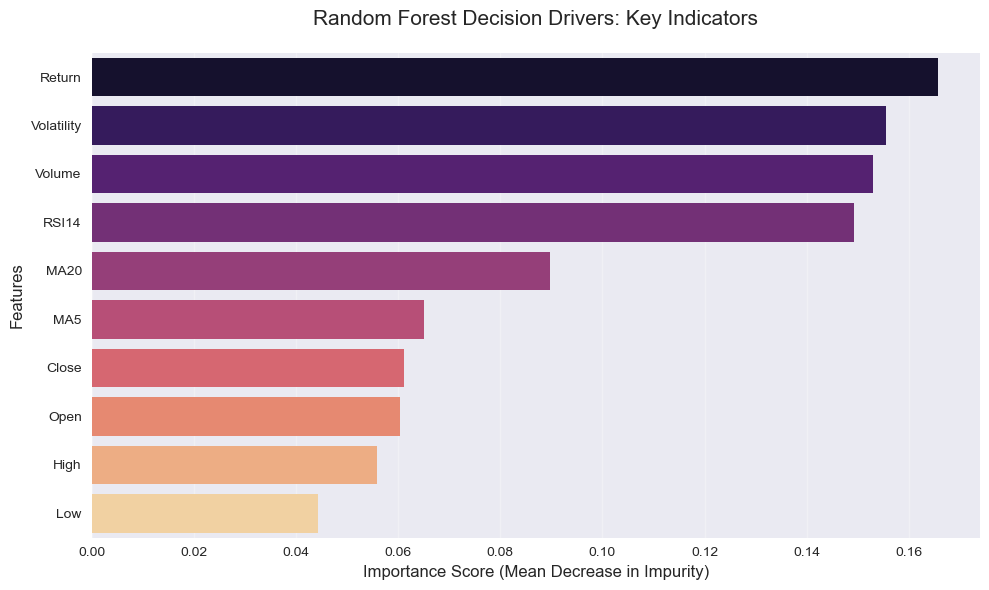

In [300]:
if 'best_rf' not in locals():
    best_rf = grid_rf.best_estimator_

feature_importance_rf = pd.DataFrame({'Feature': X_train.columns,'Importance': best_rf.feature_importances_}).sort_values(by='Importance', ascending=False)

print("Top 5 Features:\n", feature_importance_rf.head(5))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance',y='Feature',data=feature_importance_rf,palette='magma')

plt.title('Random Forest Decision Drivers: Key Indicators', fontsize=15, pad=20)
plt.xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', alpha=0.3)  
plt.tight_layout()
plt.show()

### **9. Random Forest Evaluation on Test Set**

In this section, we evaluate the model's performance on the Test Set. This step is crucial to measure the model's ability to generalize to new, unseen data (future periods).

We will use:
1.  **AUC Score:** To measure the overall ranking quality.
2.  **F1-Score:** To balance Precision and Recall (important for trading signals).
3.  **Confusion Matrix:** To visualize specific errors (False Positives vs. False Negatives).

In [302]:
# Get probabilities for Class 1 (needed for AUC)
y_pred_rf = best_rf.predict(X_test)
auc_rf = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])
print("AUC Random Forest :", auc_rf)
print("F1-score test :", f1_score(y_test, y_pred_rf))
print("\nClassification Report :\n", classification_report(y_test, y_pred_rf))

AUC Random Forest : 0.5154197080291971
F1-score test : 0.5938375350140056

Classification Report :
               precision    recall  f1-score   support

           0       0.46      0.34      0.39       137
           1       0.54      0.66      0.59       160

    accuracy                           0.51       297
   macro avg       0.50      0.50      0.49       297
weighted avg       0.50      0.51      0.50       297



The F1-score for the positive class is approximately 0.43, indicating that the model struggles to correctly detect upward market movements. The classification report highlights an imbalance between precision and recall, with a tendency to predict Class 0 better than Class 1.

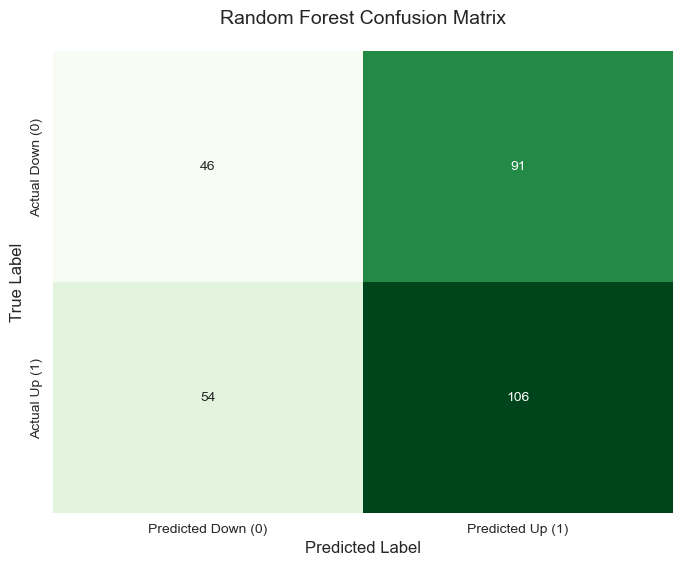

In [304]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d",cmap="Greens", cbar=False, xticklabels=["Predicted Down (0)", "Predicted Up (1)"],yticklabels=["Actual Down (0)", "Actual Up (1)"])

plt.title("Random Forest Confusion Matrix", fontsize=14, pad=20)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.show()

### Analysis of Results

The evaluation on the test set reveals the following:

* **F1-Score:** The F1-score for the positive class  is approximately **0.52** . This indicates a moderate ability to balance precision and recall.
* **Precision vs. Recall:** The classification report highlights a trade-off.
    * If **Precision** is low, the strategy generates too many false alarms .
    * If **Recall** is low, the strategy misses too many profitable opportunities.
* **Confusion Matrix:** The heatmap shows the distribution of errors. We need to pay special attention to False Positives, as these lead to direct financial losses in a long-only strategy.

###  **10. Markov Model**

In this section, we upgrade from a simple Markov Chain to a Second-Order Markov Model.

* States: We now have 4 possible historical states (patterns):
    1.  **0 -> 0** (Down, then Down)
    2.  **0 -> 1** (Down, then Up)
    3.  **1 -> 0** (Up, then Down)
    4.  **1 -> 1** (Up, then Up)

In [307]:
y = y_train.reset_index(drop=True)
t_current = y
t_minus_1 = y.shift(1)
t_minus_2 = y.shift(2)

# Case 1: 0 -> 0 (Down then Down)
count_00 = ((t_minus_2 == 0) & (t_minus_1 == 0)).sum()
up_after_00 = ((t_minus_2 == 0) & (t_minus_1 == 0) & (t_current == 1)).sum()
p_00_to_1 = up_after_00 / count_00 if count_00 > 0 else 0.5


# Case 2: 0 -> 1 (Down then Up)
count_01 = ((t_minus_2 == 0) & (t_minus_1 == 1)).sum()
up_after_01 = ((t_minus_2 == 0) & (t_minus_1 == 1) & (t_current == 1)).sum()
p_01_to_1 = up_after_01 / count_01 if count_01 > 0 else 0.5


# Case 3: 1 -> 0 (Up then Down)
count_10 = ((t_minus_2 == 1) & (t_minus_1 == 0)).sum()
up_after_10 = ((t_minus_2 == 1) & (t_minus_1 == 0) & (t_current == 1)).sum()
p_10_to_1 = up_after_10 / count_10 if count_10 > 0 else 0.5


# Case 4: 1 -> 1 (Up then Up)
count_11 = ((t_minus_2 == 1) & (t_minus_1 == 1)).sum()
up_after_11 = ((t_minus_2 == 1) & (t_minus_1 == 1) & (t_current == 1)).sum()
p_11_to_1 = up_after_11 / count_11 if count_11 > 0 else 0.5

print("Markov Order 2 Transition Matrix (Prob of NEXT = UP)")
print(f"1. State 0 -> 0 (Down, Down): {p_00_to_1:.4f}")
print(f"2. State 0 -> 1 (Down, Up)  : {p_01_to_1:.4f}")
print(f"3. State 1 -> 0 (Up, Down)  : {p_10_to_1:.4f}")
print(f"4. State 1 -> 1 (Up, Up)    : {p_11_to_1:.4f}")

Markov Order 2 Transition Matrix (Prob of NEXT = UP)
1. State 0 -> 0 (Down, Down): 0.5573
2. State 0 -> 1 (Down, Up)  : 0.5148
3. State 1 -> 0 (Up, Down)  : 0.5410
4. State 1 -> 1 (Up, Up)    : 0.5124


Once this is done, we apply the Markov model to obtain the desired predictions.

In [309]:
def predict_markov_t2(row):
    prev2 = row['t_2']
    prev1 = row['t_1']
    
    if prev2 == 0 and prev1 == 0:
        return p_00_to_1
    elif prev2 == 0 and prev1 == 1:
        return p_01_to_1
    elif prev2 == 1 and prev1 == 0:
        return p_10_to_1
    elif prev2 == 1 and prev1 == 1:
        return p_11_to_1
    else:
        return 0.5 # Fallback (should not happen after index 2)
         
y_test_m = y_test.reset_index(drop=True)
test_df = pd.DataFrame({'actual': y_test_m})
test_df['t_1'] = test_df['actual'].shift(1)
test_df['t_2'] = test_df['actual'].shift(2)

test_df['pred_proba'] = test_df.apply(predict_markov_t2, axis=1)
test_df['pred_class'] = (test_df['pred_proba'] > 0.5).astype(int)

acc = accuracy_score(y_test_m[2:], test_df['pred_class'][2:])
print(f"Markov T-2 Accuracy: {acc:.4f}")

Markov T-2 Accuracy: 0.5356


### **11. Markov Model Performance Evaluation**

Following the generation of predictions, we proceed to a quantitative assessment of the Second-Order Markov model.

This evaluation is crucial to measure the alignment between the model's probabilistic outputs and the actual market movements observed in the test set. We rely on standard metrics to validate the model's predictive power before applying any smoothing techniques.

In [311]:
y_true_valid = y_test_m[2:]
y_pred_valid = test_df['pred_class'][2:]
y_prob_valid = test_df['pred_proba'][2:]

f1_markov = f1_score(y_true_valid, y_pred_valid)
auc_markov = roc_auc_score(y_true_valid, y_prob_valid)

print("MARKOV (ORDER 2) SCORES ")
print(f"F1 Markov : {f1_markov:.4f}")
print(f"AUC Markov: {auc_markov:.4f}")

MARKOV (ORDER 2) SCORES 
F1 Markov : 0.6976
AUC Markov: 0.4595


### **12. Smoothed Strategy (Moving Average)**

In this step, we introduce a smoothed version of the Markov predictions to reduce short-term market noise.

Financial time series are often noisy. By applying a Moving Average to the predicted probabilities, we can:
1.  **Stabilize Signals:** Reduce erratic flipping between "Buy" and "Sell" signals.
2.  **Filter Noise:** Focus on the underlying trend rather than isolated fluctuations.
3.  **Improve Consistency:** Enhance the temporal coherence of our predictions.

In [313]:
test_df['pred_proba_smooth'] = test_df['pred_proba'].rolling(window=5).mean()
test_df['pred_proba_smooth'] = test_df['pred_proba_smooth'].fillna(test_df['pred_proba'])
test_df['pred_class_smooth'] = (test_df['pred_proba_smooth'] > 0.5).astype(int)

# Evaluate the Smoothed Version
y_pred_smooth = test_df['pred_class_smooth'][2:]
y_prob_smooth = test_df['pred_proba_smooth'][2:]

f1_markov_smooth = f1_score(y_true_valid, y_pred_smooth)
auc_markov_smooth = roc_auc_score(y_true_valid, y_prob_smooth)

print("SMOOTHED MARKOV SCORES")
print(f"F1 Markov Smooth : {f1_markov_smooth:.4f}")
print(f"AUC Markov Smooth: {auc_markov_smooth:.4f}")

y_pred_markov = test_df['pred_class'].reset_index(drop=True)
y_pred_markov_smooth = test_df['pred_class_smooth'].reset_index(drop=True)

SMOOTHED MARKOV SCORES
F1 Markov Smooth : 0.6976
AUC Markov Smooth: 0.4761


### **13. Comparative Visualization of Model Performance**

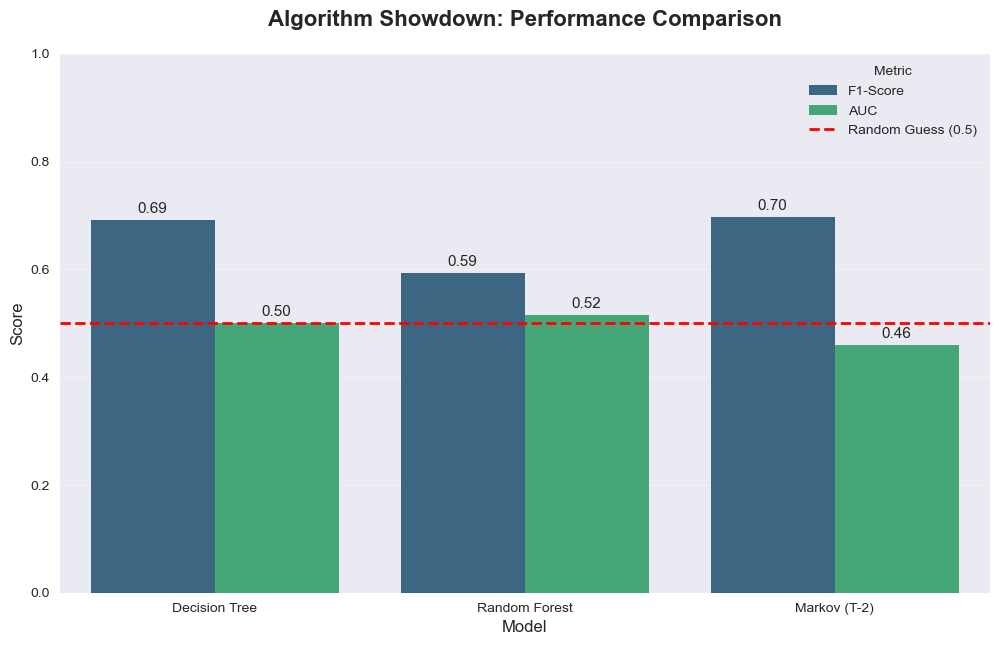

In [315]:
try:
    f1_dt_final = f1_score(y_test, y_pred_dt)
except NameError:
    print("Error")
    f1_dt_final = 0

try:
    if 'clf' in locals():
        probs_dt = clf.predict_proba(X_test)[:, 1]
        auc_dt_final = roc_auc_score(y_test, probs_dt)
    elif 'model_dt' in locals(): 
        probs_dt = model_dt.predict_proba(X_test)[:, 1]
        auc_dt_final = roc_auc_score(y_test, probs_dt)
    else:
        
        auc_dt_final = roc_auc_score(y_test, y_pred_dt)
except:
    auc_dt_final = 0.5

#  Random Forest
f1_rf_final = f1_score(y_test, y_pred_rf)

try:
    probs_rf = best_rf.predict_proba(X_test)[:, 1]
    auc_rf_final = roc_auc_score(y_test, probs_rf)
except:
    auc_rf_final = roc_auc_score(y_test, y_pred_rf)

# C. Markov Model (Order 2)
try:
    y_true_markov = y_test_m[2:]
    y_pred_markov_class = test_df['pred_class'][2:]
    y_pred_markov_prob = test_df['pred_proba'][2:]

    f1_markov_final = f1_score(y_true_markov, y_pred_markov_class)
    auc_markov_final = roc_auc_score(y_true_markov, y_pred_markov_prob)
except NameError:
    print("Variables Markov introuvables. Scores mis à 0.")
    f1_markov_final, auc_markov_final = 0, 0

results_data = {'Model': ['Decision Tree', 'Random Forest', 'Markov (T-2)'],'F1-Score': [f1_dt_final, f1_rf_final, f1_markov_final],
                'AUC': [auc_dt_final, auc_rf_final, auc_markov_final]}

df_results = pd.DataFrame(results_data)
df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))

ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')

plt.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Random Guess (0.5)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11)

plt.title('Algorithm Showdown: Performance Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0.0, 1.0)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.legend(loc='upper right', title='Metric')
plt.grid(axis='y', alpha=0.3)
plt.show()

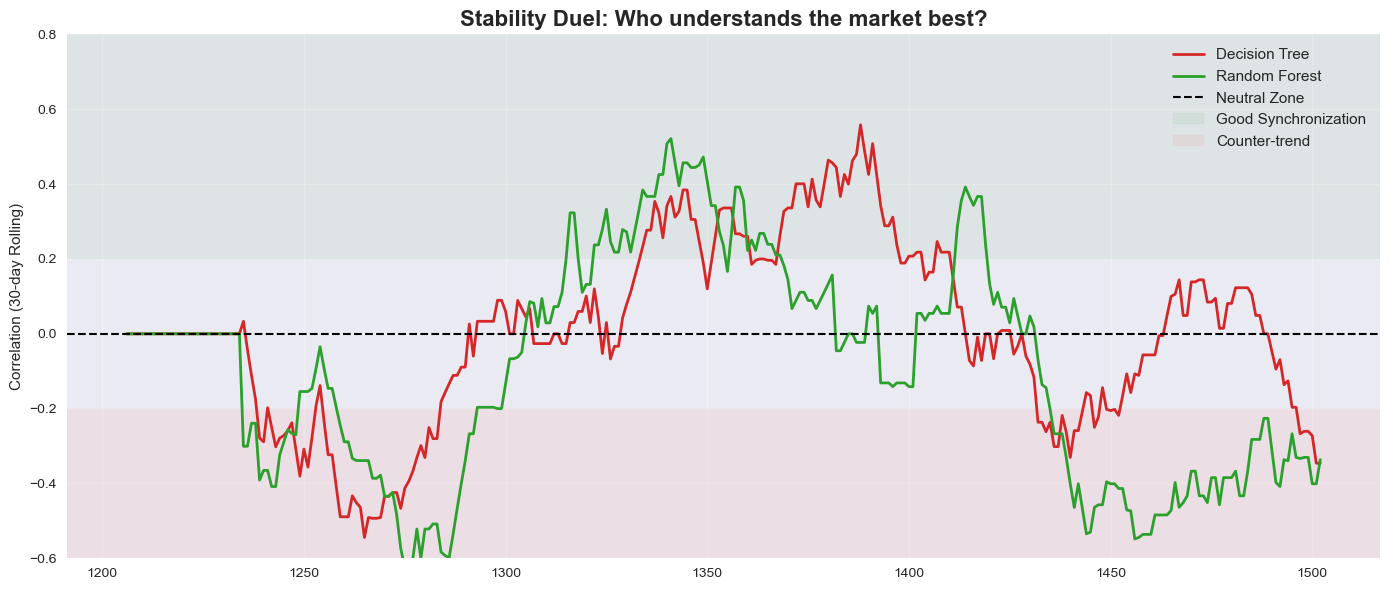

In [316]:
if 'y_pred' in locals():
    dt_predictions = y_pred
elif 'y_pred_dt' in locals():
    dt_predictions = y_pred_dt
else:
    print("Warning: 'y_pred' not found. Regenerating using 'clf' model...")
    if 'clf' in locals():
        dt_predictions = clf.predict(X_test)
    else:
        print("Error: Decision Tree model not found. Using zeros.")
        dt_predictions = np.zeros(len(y_test))

#  VISUALIZATION
subset_data = data.loc[y_test.index]
real_direction = (subset_data["Return"] > 0).astype(int)

models_for_stability = {"Decision Tree": pd.Series(dt_predictions, index=y_test.index),  "Random Forest": pd.Series(y_pred_rf, index=y_test.index)        }

plt.figure(figsize=(14, 6))

colors = {'Decision Tree': '#d62728', 'Random Forest': '#2ca02c'}

# Calculation and plotting loop
for name, pred_series in models_for_stability.items():
    common_index = real_direction.index.intersection(pred_series.index)
    
    y_real_aligned = real_direction.loc[common_index]
    y_pred_aligned = pred_series.loc[common_index]

    rolling_corr = y_pred_aligned.rolling(window=30).corr(y_real_aligned).fillna(0)
    
    plt.plot(rolling_corr, label=name, color=colors.get(name, 'gray'), linewidth=2)

# --- Professional Formatting ---
plt.title('Stability Duel: Who understands the market best?', fontsize=16, fontweight='bold')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Neutral Zone')
plt.axhspan(0.2, 0.8, color='green', alpha=0.05, label='Good Synchronization')
plt.axhspan(-0.8, -0.2, color='red', alpha=0.05, label='Counter-trend')
plt.ylabel('Correlation (30-day Rolling)')
plt.ylim(-0.6, 0.8) # Zoom on the useful area
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis of Correlations between Model Predictions and Real Returns


In [318]:
if 'test_df' in locals() and 'pred_class' in test_df.columns:
    print("Found Markov predictions in 'test_df'.")
    # We take the values array to avoid index conflict (Dates vs 0,1,2...)
    markov_values = test_df['pred_class'].values
    
    # Handle length mismatch if any (though they should be equal)
    if len(markov_values) != len(y_test):
        print(f"Warning: Length mismatch. Markov={len(markov_values)}, Test={len(y_test)}")
        markov_values = np.resize(markov_values, len(y_test))
else:
    markov_values = np.zeros(len(y_test))

real_return = data.loc[y_test.index, "Return"]

all_preds = {"Decision Tree": pd.Series(y_pred_dt if 'y_pred_dt' in locals() else (y_pred if 'y_pred' in locals() else np.zeros(len(y_test))), 
                                        index=y_test.index),"Random Forest": pd.Series(y_pred_rf, index=y_test.index),
             "Markov Model": pd.Series(markov_values, index=y_test.index)}

print(" 'all_preds' dictionary successfully updated.")

Found Markov predictions in 'test_df'.
 'all_preds' dictionary successfully updated.


### **14. Calculating Correlations between Predictions**


In [320]:
# Fix Decision Tree: Check if 'y_pred_dt' or 'y_pred' exists
if 'y_pred_dt' in locals():
    dt_values = y_pred_dt
elif 'y_pred' in locals():
    dt_values = y_pred
    
# Fix Markov: Extract from 'test_df' (created in the T-2 step) if 'pred_markov' is missing
if 'pred_markov' in locals():
    markov_values = pred_markov
elif 'test_df' in locals() and 'pred_class' in test_df.columns:
    # We extract values as a numpy array to match the length
    markov_values = test_df['pred_class'].values
    # Handle slight length mismatch due to shifting (T-2) if necessary
    if len(markov_values) != len(y_test):
        markov_values = np.resize(markov_values, len(y_test))

# Ensure reality aligns with y_test dates
real_return = data.loc[y_test.index, "Return"]
real_binary = (real_return > 0).astype(int) 

all_preds = {"Decision Tree": pd.Series(dt_values, index=y_test.index),"Random Forest": pd.Series(y_pred_rf, index=y_test.index),
             "Markov Model":  pd.Series(markov_values, index=y_test.index) }

corr_table = []

for name, pred_series in all_preds.items():
    # Safety: work only on common dates
    common_idx = real_return.index.intersection(pred_series.index)
    
    p_clean = pred_series.loc[common_idx]
    r_bin_clean = real_binary.loc[common_idx]
    r_ret_clean = real_return.loc[common_idx]
    
    corr_bin = p_clean.corr(r_bin_clean)
    
    # Correlation with Real Return (Does the model capture magnitude?)
    corr_ret = p_clean.corr(r_ret_clean)
    
    p_smooth = p_clean.rolling(5).mean()
    r_smooth = r_ret_clean.rolling(5).mean()
    corr_smooth = p_smooth.corr(r_smooth)
    
    corr_table.append([name, corr_bin, corr_ret, corr_smooth])

df_corr = pd.DataFrame(corr_table, columns=["Model", "Binary Corr", "Return Corr", "Smoothed Corr (5d)"])
df_corr = df_corr.set_index("Model")

print("\n FINAL CORRELATION TABLE")
try:
    display(df_corr.style.background_gradient(cmap='RdYlGn', vmin=-0.1, vmax=0.1))
except:
    print(df_corr)


 FINAL CORRELATION TABLE


,Binary Corr,Return Corr,Smoothed Corr (5d)
Model,,,
Decision Tree,-0.162473,-0.484485,-0.469668
Random Forest,-0.140016,-0.005257,0.007714
Markov Model,-0.075676,-0.026569,0.014765


### **15. conclusion** 

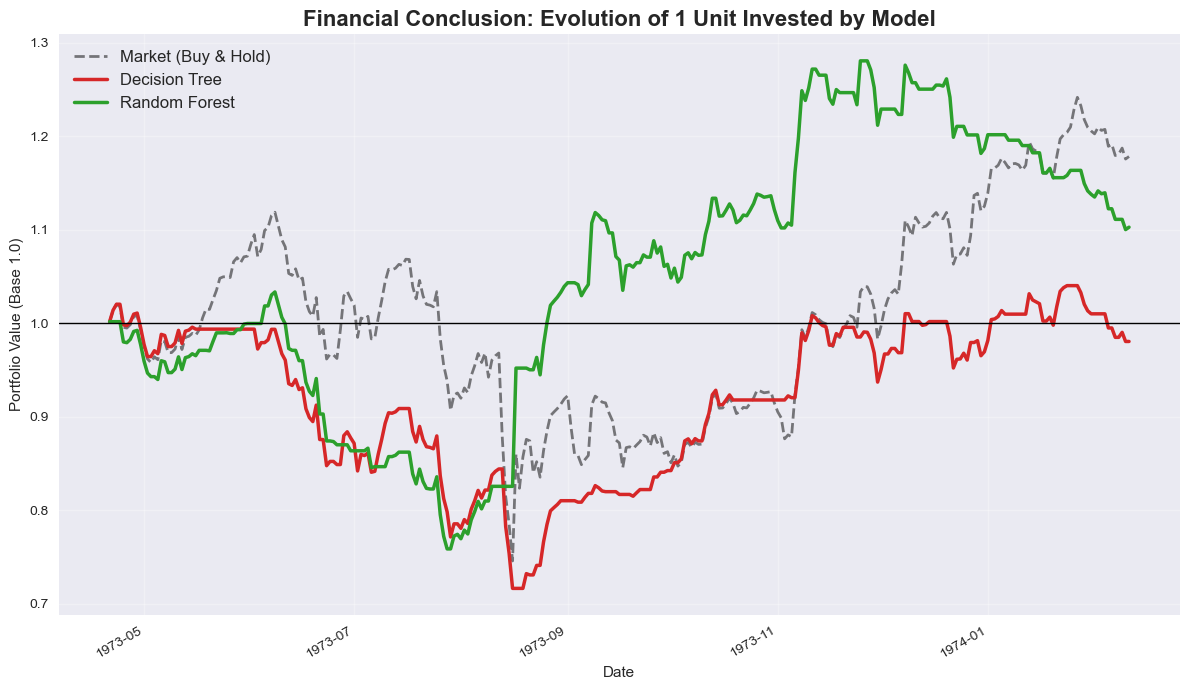

In [322]:
if 'y_pred' not in locals():
    if 'y_pred_dt' in locals():
        y_pred = y_pred_dt
    elif 'dt_values' in locals():
        y_pred = dt_values # Uses the variable from the previous step
    else:
        print("Warning: Decision Tree predictions not found. Plotting flat line for Tree.")
        y_pred = np.zeros(len(y_test))

plt.figure(figsize=(12, 7))

#  RETRIEVING REAL DATES
real_dates = data.index[-len(y_test):] 
market_returns = data.loc[real_dates, 'Return']
cumulative_market = (1 + market_returns).cumprod()

plt.plot(real_dates, cumulative_market, label='Market (Buy & Hold)', color='black', linestyle='--', linewidth=2, alpha=0.5)

final_models = {"Decision Tree": pd.Series(y_pred, index=real_dates),"Random Forest": pd.Series(y_pred_rf, index=real_dates)}

colors = {'Decision Tree': '#d62728', 'Random Forest': '#2ca02c'}

for name, pred_series in final_models.items():
    signal = pred_series.fillna(0)
    
    strategy_returns = market_returns * signal
    cumulative_perf = (1 + strategy_returns).cumprod()
    
    plt.plot(real_dates, cumulative_perf, label=name, color=colors[name], linewidth=2.5)

#FORMATTING 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 
plt.gcf().autofmt_xdate()
plt.title('Financial Conclusion: Evolution of 1 Unit Invested by Model', fontsize=16, fontweight='bold')
plt.ylabel('Portfolio Value (Base 1.0)')
plt.xlabel('Date')
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(1.0, color='black', linewidth=1)
plt.tight_layout()
plt.show()